## STAT 306 Project: Vancouver Land Value Associated with Prior Year Values and Age

In [76]:
library(tidyverse)
library(dplyr)
library(broom)
library(ggplot2)
library(car)
library(GGally)
library(broom)

--------------------------
#### Data cleaning

In [77]:


property <- read.csv(
  file = "./data/sample_data.csv"
) |>
  subset(select = c(CURRENT_LAND_VALUE,
    PREVIOUS_LAND_VALUE,
    PREVIOUS_IMPROVEMENT_VALUE,
    YEAR_BUILT, ZONING_CLASSIFICATION,
    LEGAL_TYPE
  )) |>
  na.omit()

property2 <- subset(property,
  is.finite(CURRENT_LAND_VALUE) & CURRENT_LAND_VALUE > 1 &
  is.finite(PREVIOUS_LAND_VALUE) & PREVIOUS_LAND_VALUE > 1 &
  is.finite(PREVIOUS_IMPROVEMENT_VALUE) & PREVIOUS_IMPROVEMENT_VALUE > 1 &
  is.finite(YEAR_BUILT)
)


nrow(property) - nrow(property2) ## we check how many rows were dropped
sample_n(property, 10) ## looking at our data


[1] 6

CURRENT_LAND_VALUE,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT,ZONING_CLASSIFICATION,LEGAL_TYPE
<dbl>,<dbl>,<int>,<int>,<chr>,<chr>
3766000,3468000,10000,1945,Residential,LAND
353000,373000,236000,2007,Comprehensive Development,STRATA
1292000,1504000,300000,2006,Comprehensive Development,STRATA
637000,593000,158000,2008,Comprehensive Development,STRATA
551000,561000,215000,1957,Comprehensive Development,STRATA
1314000,1169000,115000,1978,One-Family Dwelling,LAND
715000,808000,129000,1985,Residential,STRATA
207000,228000,128000,1994,Comprehensive Development,STRATA
637000,659000,354000,2018,Multiple Dwelling,STRATA


In [78]:
# See how many variables in ZONING CLASSIFICATION

unique(property$ZONING_CLASSIFICATION)
length(unique(property$ZONING_CLASSIFICATION))

[1] "Residential Inclusive"     "One-Family Dwelling"      
 [3] "Comprehensive Development" "Industrial"               
 [5] "Commercial"                "Multiple Dwelling"        
 [7] "Residential"               "Two-Family Dwelling"      
 [9] "Historical Area"           "Other"                    
[11] ""                          "Limited Agriculture"

[1] 12

In [79]:
# See what missing values in ZONING CLASSIFICATION

property[property$ZONING_CLASSIFICATION == '',]

,CURRENT_LAND_VALUE,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT,ZONING_CLASSIFICATION,LEGAL_TYPE
,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>
175,537000,609000,145000,2017,,STRATA
605,320000,310000,166000,2018,,STRATA
991,1523000,1811000,126000,1983,,LAND
1511,494000,551000,298000,2018,,STRATA
1676,520000,503000,281000,2018,,STRATA
1890,300000,350000,187000,2018,,STRATA
1946,420000,491000,261000,2018,,STRATA
1985,732000,822000,349000,2017,,STRATA


In [80]:
# Simplify ZONING CLASSIFICATION into 5 categories: Residential, Commercial, Industrial, Agriculture, Special

property2$ZONE_SIMPLE <- dplyr::case_when(
  property2$ZONING_CLASSIFICATION %in% c(
    "Residential Inclusive",
    "One-Family Dwelling",
    "Two-Family Dwelling",
    "Multiple Dwelling",
    "Residential"
  ) ~ "Residential",

  property2$ZONING_CLASSIFICATION == "Commercial" ~ "Commercial",

  property2$ZONING_CLASSIFICATION == "Industrial" ~ "Industrial",

  property2$ZONING_CLASSIFICATION == "Limited Agriculture" ~ "Agriculture",
  property2$ZONING_CLASSIFICATION %in% c(
    "Comprehensive Development",
    "Historical Area",
    "",
    "Other"
  ) ~ "Special"
)

In [81]:
unique(property$ZONE_SIMPLE)
length(unique(property$ZONE_SIMPLE))

NULL

[1] 0

In [82]:
colSums(is.na(property))

CURRENT_LAND_VALUE        PREVIOUS_LAND_VALUE 
                         0                          0 
PREVIOUS_IMPROVEMENT_VALUE                 YEAR_BUILT 
                         0                          0 
     ZONING_CLASSIFICATION                 LEGAL_TYPE 
                         0                          0

In [83]:
table(property2$LEGAL_TYPE)
## there is only one OTHER legal type so we decicded to drop it as outlier
nrow(property2)  


  LAND  OTHER STRATA 
   754      1   1142 

[1] 1897

In [84]:
property2 <- property2[property2$LEGAL_TYPE != "OTHER", ]
property2 <- property2 %>% select(-ZONING_CLASSIFICATION)
nrow(property2)  # should be 1 less than before

[1] 1896

--------------------------
#### Model selection


In [85]:
# Define null and full model
fit_null <- lm(log(CURRENT_LAND_VALUE) ~ 1, data = property2)

fit_full <- lm(log(CURRENT_LAND_VALUE) ~ ., data = property2)

# Full stepwise (both directions)
fit_step <- step(fit_null, 
                 direction = "both", 
                 scope = formula(fit_full))

# Start from full model, remove predictors one by one
fit_backward <- step(fit_full, direction = "backward")

# Start from null, add predictors one by one
fit_forward <- step(fit_null, direction = "forward", scope = formula(fit_full))

# Summary of chosen model
cat("Stepwise Selection (both directions):")
summary(fit_step)
AIC(fit_step)

cat("Backward Selection:")
summary(fit_backward)
AIC(fit_backward)

cat("Forward Selection:")
summary(fit_forward)
AIC(fit_forward)

Start:  AIC=-463.85
log(CURRENT_LAND_VALUE) ~ 1

                             Df Sum of Sq    RSS      AIC
+ LEGAL_TYPE                  1    735.46  747.5 -1760.73
+ PREVIOUS_LAND_VALUE         1    375.34 1107.6 -1015.14
+ ZONE_SIMPLE                 4    366.99 1116.0  -994.91
+ YEAR_BUILT                  1    235.99 1247.0  -790.46
+ PREVIOUS_IMPROVEMENT_VALUE  1    135.79 1347.2  -643.93
<none>                                    1483.0  -463.85

Step:  AIC=-1760.73
log(CURRENT_LAND_VALUE) ~ LEGAL_TYPE

                             Df Sum of Sq     RSS      AIC
+ PREVIOUS_LAND_VALUE         1    176.57  570.94 -2269.62
+ PREVIOUS_IMPROVEMENT_VALUE  1     80.46  667.05 -1974.64
+ ZONE_SIMPLE                 4     15.33  732.17 -1792.03
<none>                                     747.50 -1760.73
+ YEAR_BUILT                  1      0.08  747.42 -1758.94
- LEGAL_TYPE                  1    735.46 1482.97  -463.85

Step:  AIC=-2269.62
log(CURRENT_LAND_VALUE) ~ LEGAL_TYPE + PREVIOUS_LAND


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ LEGAL_TYPE + PREVIOUS_LAND_VALUE + 
    ZONE_SIMPLE, data = property2)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.9837 -0.2874 -0.0674  0.2734  1.9533 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)             1.151e+01  5.432e-01  21.184  < 2e-16 ***
LEGAL_TYPESTRATA       -1.023e+00  3.665e-02 -27.915  < 2e-16 ***
PREVIOUS_LAND_VALUE     6.766e-08  2.754e-09  24.570  < 2e-16 ***
ZONE_SIMPLECommercial   2.782e+00  5.437e-01   5.117 3.43e-07 ***
ZONE_SIMPLEIndustrial   3.046e+00  5.470e-01   5.569 2.94e-08 ***
ZONE_SIMPLEResidential  2.860e+00  5.429e-01   5.269 1.53e-07 ***
ZONE_SIMPLESpecial      2.714e+00  5.423e-01   5.004 6.15e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.542 on 1889 degrees of freedom
Multiple R-squared:  0.6259,	Adjusted R-squared:  0.6247 
F-statistic: 526.6 on 6 and 1889 DF,  p-value: < 2.2e-16


[1] 3066.809

Backward Selection:


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ PREVIOUS_LAND_VALUE + 
    LEGAL_TYPE + ZONE_SIMPLE, data = property2)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.9837 -0.2874 -0.0674  0.2734  1.9533 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)             1.151e+01  5.432e-01  21.184  < 2e-16 ***
PREVIOUS_LAND_VALUE     6.766e-08  2.754e-09  24.570  < 2e-16 ***
LEGAL_TYPESTRATA       -1.023e+00  3.665e-02 -27.915  < 2e-16 ***
ZONE_SIMPLECommercial   2.782e+00  5.437e-01   5.117 3.43e-07 ***
ZONE_SIMPLEIndustrial   3.046e+00  5.470e-01   5.569 2.94e-08 ***
ZONE_SIMPLEResidential  2.860e+00  5.429e-01   5.269 1.53e-07 ***
ZONE_SIMPLESpecial      2.714e+00  5.423e-01   5.004 6.15e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.542 on 1889 degrees of freedom
Multiple R-squared:  0.6259,	Adjusted R-squared:  0.6247 
F-statistic: 526.6 on 6 and 1889 DF,  p-value: < 2.2e-16


[1] 3066.809

Forward Selection:


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ LEGAL_TYPE + PREVIOUS_LAND_VALUE + 
    ZONE_SIMPLE, data = property2)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.9837 -0.2874 -0.0674  0.2734  1.9533 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)             1.151e+01  5.432e-01  21.184  < 2e-16 ***
LEGAL_TYPESTRATA       -1.023e+00  3.665e-02 -27.915  < 2e-16 ***
PREVIOUS_LAND_VALUE     6.766e-08  2.754e-09  24.570  < 2e-16 ***
ZONE_SIMPLECommercial   2.782e+00  5.437e-01   5.117 3.43e-07 ***
ZONE_SIMPLEIndustrial   3.046e+00  5.470e-01   5.569 2.94e-08 ***
ZONE_SIMPLEResidential  2.860e+00  5.429e-01   5.269 1.53e-07 ***
ZONE_SIMPLESpecial      2.714e+00  5.423e-01   5.004 6.15e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.542 on 1889 degrees of freedom
Multiple R-squared:  0.6259,	Adjusted R-squared:  0.6247 
F-statistic: 526.6 on 6 and 1889 DF,  p-value: < 2.2e-16


[1] 3066.809

In [86]:
fit_step$call        # see the final formula
coef(fit_step)       # coefficients kept

fit_backward$call
coef(fit_backward)  

fit_forward$call
coef(fit_forward)   

lm(formula = log(CURRENT_LAND_VALUE) ~ LEGAL_TYPE + PREVIOUS_LAND_VALUE + 
    ZONE_SIMPLE, data = property2)

(Intercept)       LEGAL_TYPESTRATA    PREVIOUS_LAND_VALUE 
          1.150752e+01          -1.023165e+00           6.765835e-08 
 ZONE_SIMPLECommercial  ZONE_SIMPLEIndustrial ZONE_SIMPLEResidential 
          2.781848e+00           3.045984e+00           2.860181e+00 
    ZONE_SIMPLESpecial 
          2.713727e+00

lm(formula = log(CURRENT_LAND_VALUE) ~ PREVIOUS_LAND_VALUE + 
    LEGAL_TYPE + ZONE_SIMPLE, data = property2)

(Intercept)    PREVIOUS_LAND_VALUE       LEGAL_TYPESTRATA 
          1.150752e+01           6.765835e-08          -1.023165e+00 
 ZONE_SIMPLECommercial  ZONE_SIMPLEIndustrial ZONE_SIMPLEResidential 
          2.781848e+00           3.045984e+00           2.860181e+00 
    ZONE_SIMPLESpecial 
          2.713727e+00

lm(formula = log(CURRENT_LAND_VALUE) ~ LEGAL_TYPE + PREVIOUS_LAND_VALUE + 
    ZONE_SIMPLE, data = property2)

(Intercept)       LEGAL_TYPESTRATA    PREVIOUS_LAND_VALUE 
          1.150752e+01          -1.023165e+00           6.765835e-08 
 ZONE_SIMPLECommercial  ZONE_SIMPLEIndustrial ZONE_SIMPLEResidential 
          2.781848e+00           3.045984e+00           2.860181e+00 
    ZONE_SIMPLESpecial 
          2.713727e+00

--------------------------
#### Fitting Models

In [87]:
fit <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE, data = property2)
bb <- coef(fit)
# bb
fit_both <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE + LEGAL_TYPE, data = property2)
fit_legal <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + LEGAL_TYPE, data = property2)
fit_inter <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE)*LEGAL_TYPE + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, data = property2)
cat("Additive Model with ZONE_SIMPLE")
summary(fit)
vif(fit)
cat(" \n \n Additive Model with LEGAL_TYPE")
summary(fit_legal)
vif(fit_legal)
cat("\n \n Additive Model with both ZONE_SIMPLE and LEGAL_TYPE")
summary(fit_both)
vif(fit_both)
cat("\n \n Interaction Model with log(PREVIOUS_LAND_VALUE) and LEGAL_TYPE")
summary(fit_inter)
# vif(fit_inter)

Additive Model with ZONE_SIMPLE


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE, 
    data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.59376 -0.05396  0.00579  0.05974  0.63020 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      1.0841631  0.2156823   5.027 5.46e-07 ***
log(PREVIOUS_LAND_VALUE)         0.9733755  0.0033383 291.582  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  0.0063467  0.0024930   2.546 0.010982 *  
YEAR_BUILT                      -0.0003454  0.0001037  -3.329 0.000887 ***
ZONE_SIMPLECommercial           -0.1076832  0.0995428  -1.082 0.279490    
ZONE_SIMPLEIndustrial           -0.0950141  0.1003574  -0.947 0.343884    
ZONE_SIMPLEResidential          -0.0819472  0.0990990  -0.827 0.408385    
ZONE_SIMPLESpecial              -0.1235898  0.0992783  -1.245 0.213329    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '

,GVIF,Df,GVIF^(1/(2*Df))
log(PREVIOUS_LAND_VALUE),1.783650,1,1.335534
log(PREVIOUS_IMPROVEMENT_VALUE),1.569356,1,1.252739
YEAR_BUILT,1.951073,1,1.396808
ZONE_SIMPLE,1.730015,4,1.070918


 
 
 Additive Model with LEGAL_TYPE


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + LEGAL_TYPE, 
    data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.61964 -0.05204  0.00772  0.05926  0.62567 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      1.1527457  0.2047054   5.631 2.06e-08 ***
log(PREVIOUS_LAND_VALUE)         0.9683067  0.0039212 246.940  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  0.0059196  0.0024810   2.386 0.017133 *  
YEAR_BUILT                      -0.0003810  0.0001023  -3.723 0.000203 ***
LEGAL_TYPESTRATA                -0.0387354  0.0072339  -5.355 9.61e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.0971 on 1891 degrees of freedom
Multiple R-squared:  0.988,	Adjusted R-squared:  0.988 
F-statistic: 3.885e+04 on 4 and 1891 DF,  p-value: < 2.2e-16


...


 
 Additive Model with both ZONE_SIMPLE and LEGAL_TYPE


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + ZONE_SIMPLE + 
    LEGAL_TYPE, data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.60148 -0.05238  0.00767  0.05814  0.62383 

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      1.0561822  0.2156172   4.898 1.05e-06 ***
log(PREVIOUS_LAND_VALUE)         0.9677184  0.0039753 243.430  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)  0.0071322  0.0025073   2.845  0.00450 ** 
YEAR_BUILT                      -0.0002894  0.0001058  -2.736  0.00628 ** 
ZONE_SIMPLECommercial           -0.1058949  0.0993922  -1.065  0.28682    
ZONE_SIMPLEIndustrial           -0.0936337  0.1002046  -0.934  0.35020    
ZONE_SIMPLEResidential          -0.0875589  0.0989700  -0.885  0.37643    
ZONE_SIMPLESpecial              -0.1214703  0.0991290  -1.225  0.22059    
LEGAL_TYPESTRATA                

,GVIF,Df,GVIF^(1/(2*Df))
log(PREVIOUS_LAND_VALUE),2.537208,1,1.592862
log(PREVIOUS_IMPROVEMENT_VALUE),1.592277,1,1.261855
YEAR_BUILT,2.034664,1,1.426417
ZONE_SIMPLE,2.211179,4,1.104277
LEGAL_TYPE,3.221939,1,1.794976



 
 Interaction Model with log(PREVIOUS_LAND_VALUE) and LEGAL_TYPE


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) * 
    LEGAL_TYPE + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, 
    data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.61208 -0.05044  0.00722  0.05789  0.61539 

Coefficients:
                                            Estimate Std. Error t value
(Intercept)                                1.4056189  0.2151331   6.534
log(PREVIOUS_LAND_VALUE)                   0.9514587  0.0059959 158.684
LEGAL_TYPESTRATA                          -0.4138718  0.1015055  -4.077
log(PREVIOUS_IMPROVEMENT_VALUE)            0.0063762  0.0024758   2.575
YEAR_BUILT                                -0.0003877  0.0001020  -3.800
log(PREVIOUS_LAND_VALUE):LEGAL_TYPESTRATA  0.0266294  0.0071873   3.705
                                          Pr(>|t|)    
(Intercept)                               8.23e-11 ***
log(PREVIOUS_LAND_VALUE)                   < 2e-16 ***
LEGAL_TYPESTRATA                          4.74e-05 *

In [88]:
AIC(fit, fit_legal, fit_both, fit_inter)

,df,AIC
,<dbl>,<dbl>
fit,9,-3470.738
fit_legal,6,-3455.571
fit_both,10,-3475.577
fit_inter,7,-3467.293


In [89]:
cat("VIF of model with ZONE_SIMPLE")
vif(fit)
cat("\n \n VIF of model with LEGAL_TYPE")
vif(fit_legal)
cat("\n \n VIF of model with both ZONE_SIMPLE and LEGAL_TYPE")
vif(fit_both)

VIF of model with ZONE_SIMPLE

,GVIF,Df,GVIF^(1/(2*Df))
log(PREVIOUS_LAND_VALUE),1.783650,1,1.335534
log(PREVIOUS_IMPROVEMENT_VALUE),1.569356,1,1.252739
YEAR_BUILT,1.951073,1,1.396808
ZONE_SIMPLE,1.730015,4,1.070918



 
 VIF of model with LEGAL_TYPE

log(PREVIOUS_LAND_VALUE) log(PREVIOUS_IMPROVEMENT_VALUE) 
                       2.437568                        1.539451 
                     YEAR_BUILT                      LEGAL_TYPE 
                       1.880941                        2.520829


 
 VIF of model with both ZONE_SIMPLE and LEGAL_TYPE

,GVIF,Df,GVIF^(1/(2*Df))
log(PREVIOUS_LAND_VALUE),2.537208,1,1.592862
log(PREVIOUS_IMPROVEMENT_VALUE),1.592277,1,1.261855
YEAR_BUILT,2.034664,1,1.426417
ZONE_SIMPLE,2.211179,4,1.104277
LEGAL_TYPE,3.221939,1,1.794976


In [90]:
fit_int_legal <- lm(log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) * LEGAL_TYPE + 
                    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, data = property2)
anova(fit_legal, fit_int_legal)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1891,17.82740,NA,NA,NA,NA
2,1890,17.69885,1,0.1285521,13.72764,0.0002173966


In [91]:
summary(fit_int_legal)


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) * 
    LEGAL_TYPE + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT, 
    data = property2)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.61208 -0.05044  0.00722  0.05789  0.61539 

Coefficients:
                                            Estimate Std. Error t value
(Intercept)                                1.4056189  0.2151331   6.534
log(PREVIOUS_LAND_VALUE)                   0.9514587  0.0059959 158.684
LEGAL_TYPESTRATA                          -0.4138718  0.1015055  -4.077
log(PREVIOUS_IMPROVEMENT_VALUE)            0.0063762  0.0024758   2.575
YEAR_BUILT                                -0.0003877  0.0001020  -3.800
log(PREVIOUS_LAND_VALUE):LEGAL_TYPESTRATA  0.0266294  0.0071873   3.705
                                          Pr(>|t|)    
(Intercept)                               8.23e-11 ***
log(PREVIOUS_LAND_VALUE)                   < 2e-16 ***
LEGAL_TYPESTRATA                          4.74e-05 *

--------------------------
#### Plots

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


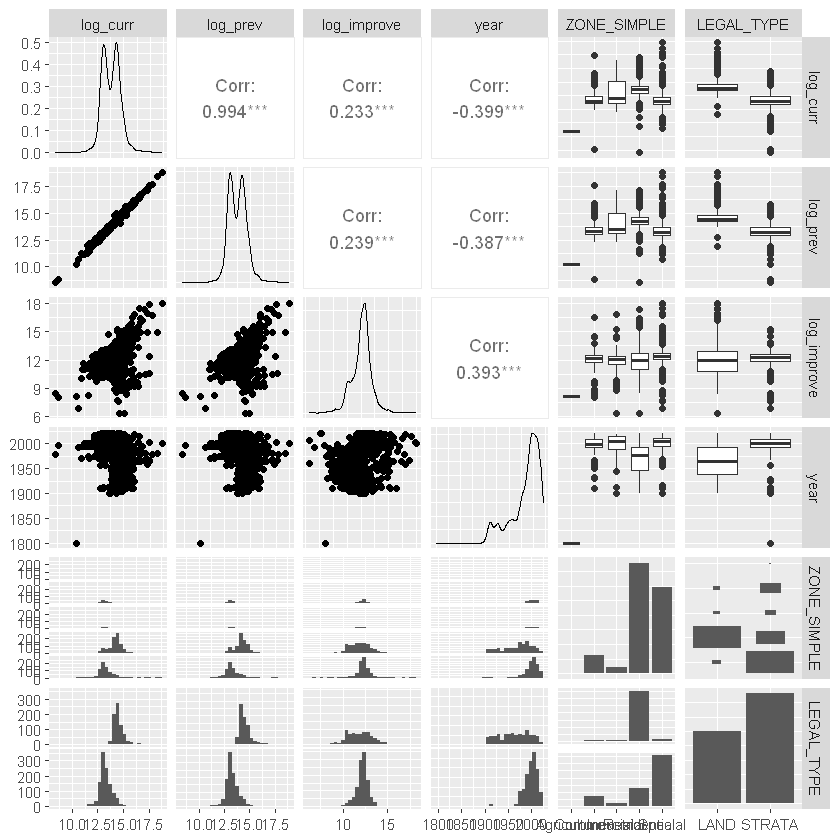

In [92]:
property_log <- property2 |>
                mutate(log_curr = log(CURRENT_LAND_VALUE),
                log_prev = log(PREVIOUS_LAND_VALUE),
                log_improve = log(PREVIOUS_IMPROVEMENT_VALUE),
                year = as.numeric(YEAR_BUILT)) |>
                select(log_curr, log_prev, log_improve, year, ZONE_SIMPLE, LEGAL_TYPE) 
ggpairs(property_log)

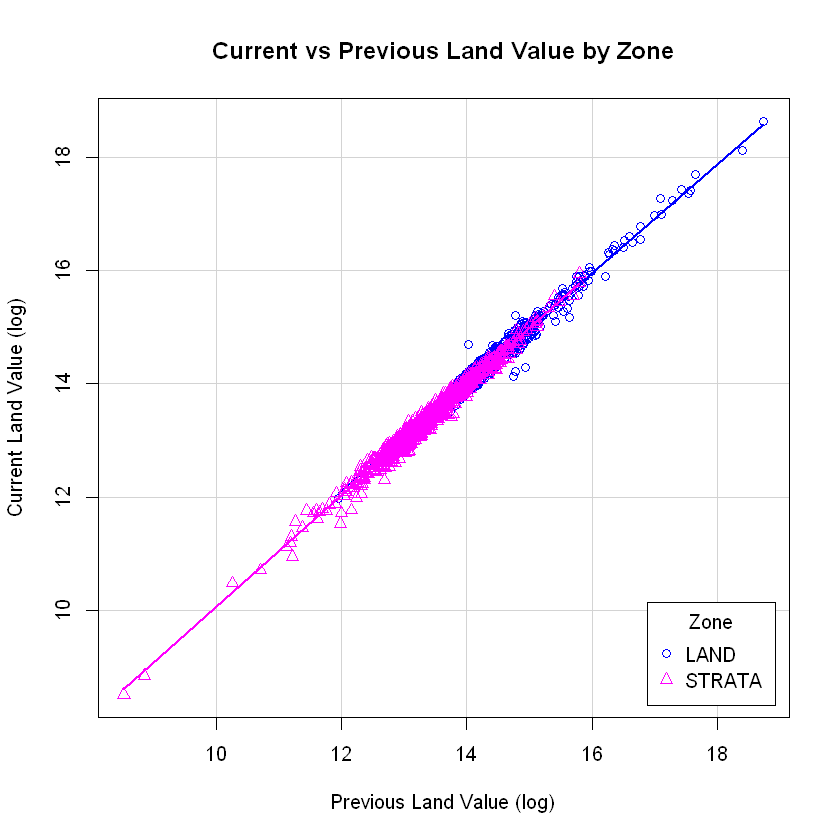

In [93]:
scatterplot(
    log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE)|LEGAL_TYPE, 
    smooth=FALSE, 
    by.groups=TRUE,
    xlab = "Previous Land Value (log)", 
    ylab = "Current Land Value (log)",
    main = "Current vs Previous Land Value by Zone",
    legend = list(title = "Zone", coords = "bottomright"),
    data = property2
    )

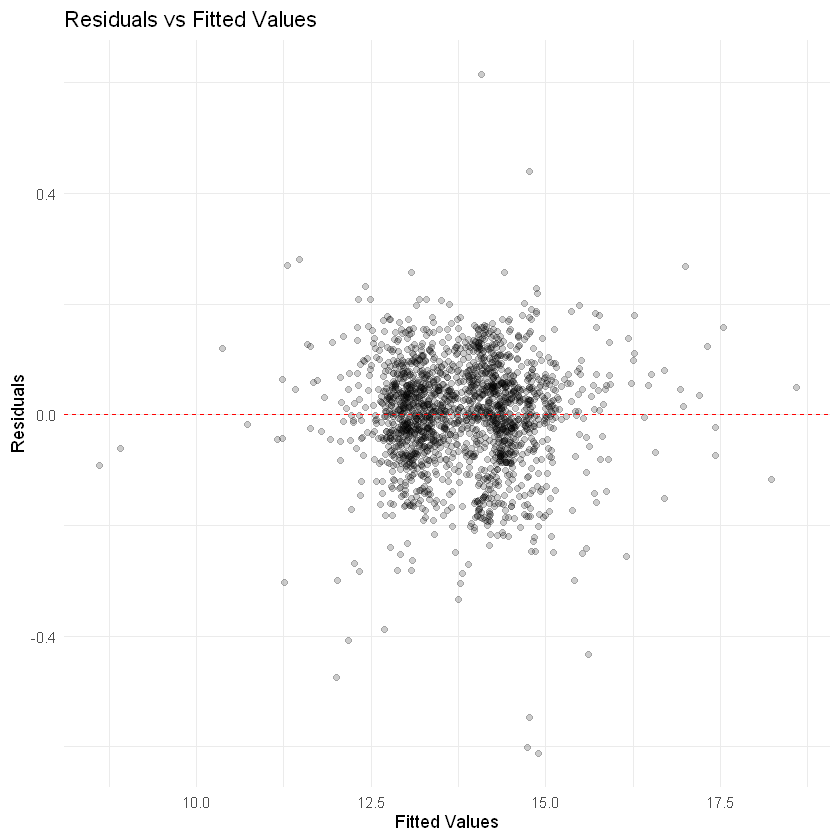

In [94]:
#ggplot2 for the red line
ggplot(data.frame(fitted = fit_int_legal$fitted.values, residuals = fit_int_legal$residuals),
       aes(x = fitted, y = residuals)) +
  geom_point(alpha = 0.2) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  labs(x = "Fitted Values", 
       y = "Residuals",
       title = "Residuals vs Fitted Values") +
  theme_minimal()

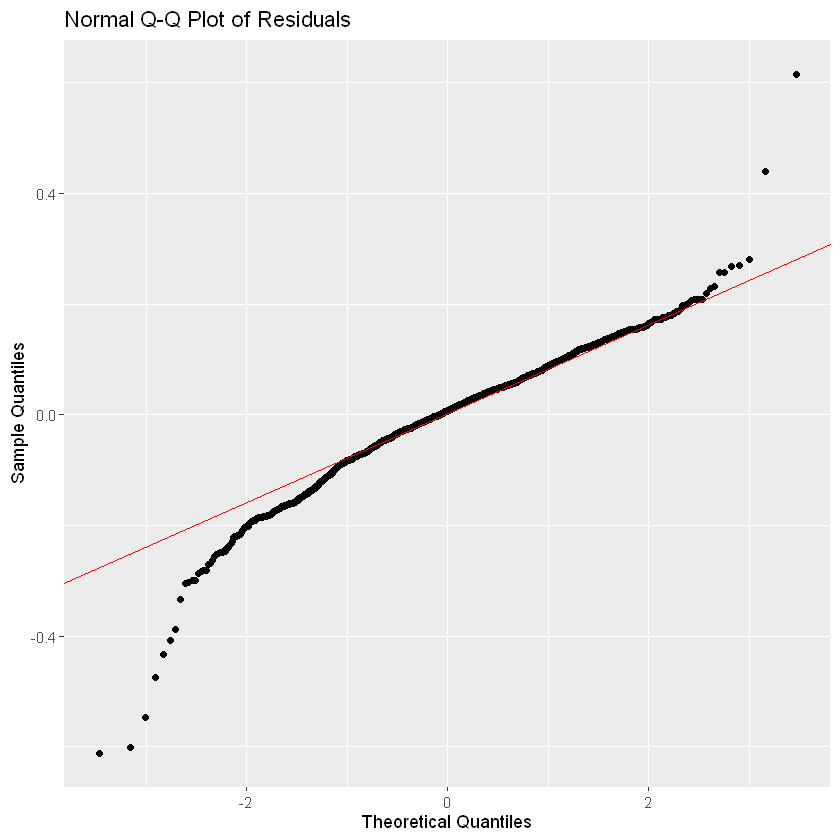

In [95]:
# ggplot2
ggplot(data.frame(resid = residuals(fit_int_legal)), aes(sample = resid)) +
  stat_qq() +
  stat_qq_line(color = "red") +
  labs(
    title = "Normal Q-Q Plot of Residuals",
    x = "Theoretical Quantiles",
    y = "Sample Quantiles"
  )

`geom_smooth()` using formula = 'y ~ x'


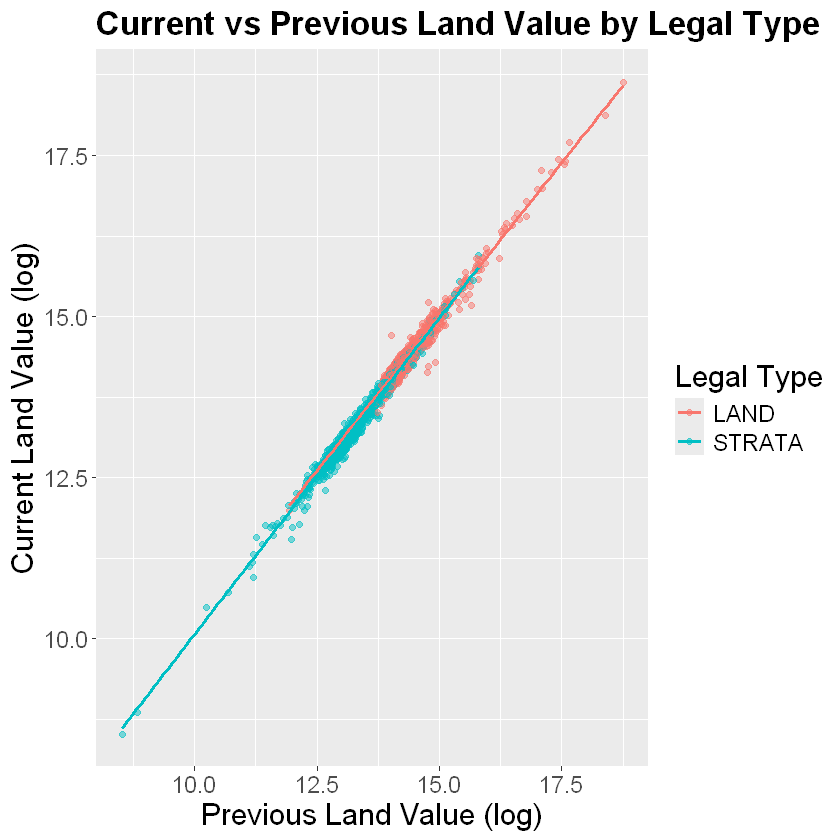

In [96]:
property2 |>
ggplot(aes(x = log(PREVIOUS_LAND_VALUE), y = log(CURRENT_LAND_VALUE), color = LEGAL_TYPE)) +
geom_jitter(alpha = 0.5) +
geom_smooth(method = "lm", se = FALSE)+
 labs(x = "Previous Land Value (log)", 
      y = "Current Land Value (log)",
      title = "Current vs Previous Land Value by Legal Type",
      color = "Legal Type") + 
    theme(
      plot.title = element_text(size = 20, face = "bold"), 
      axis.title = element_text(size = 18),              
      axis.text = element_text(size = 14),                
      legend.title = element_text(size = 18),             
      legend.text = element_text(size = 14)               
)